<a href="https://colab.research.google.com/github/Vanshika-code28/student-behavior-analyzer/blob/main/Student_Performance_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

data = pd.read_csv("student_data.csv")

data.head()


,StudyHours,SleepHours,Attendance,MobileUsage,Marks
0,2,5,60,5,40
1,3,6,65,4,45
2,4,6,70,3,55
3,5,7,75,3,60
4,6,7,80,2,68


In [2]:
print(data.shape)
print(data.describe())

(30, 5)
       StudyHours  SleepHours  Attendance  MobileUsage      Marks
count   30.000000   30.000000   30.000000    30.000000  30.000000
mean     4.733333    6.666667   73.266667     3.033333  60.433333
std      2.211776    1.154701   12.099967     1.496740  17.167900
min      1.000000    4.000000   50.000000     1.000000  30.000000
25%      3.000000    6.000000   65.000000     2.000000  47.250000
50%      5.000000    7.000000   73.000000     3.000000  60.500000
75%      6.750000    8.000000   82.750000     4.000000  72.750000
max      8.000000    8.000000   92.000000     6.000000  88.000000


In [3]:
data['Result'] = data['Marks'].apply(lambda x: 1 if x >= 50 else 0)

data.head()

,StudyHours,SleepHours,Attendance,MobileUsage,Marks,Result
0,2,5,60,5,40,0
1,3,6,65,4,45,0
2,4,6,70,3,55,1
3,5,7,75,3,60,1
4,6,7,80,2,68,1


In [4]:
X = data[['StudyHours', 'SleepHours', 'Attendance', 'MobileUsage']]
y = data['Result']

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [7]:
predictions = model.predict(X_test)

In [8]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.8333333333333334


In [9]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

cm = confusion_matrix(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)

print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)

Confusion Matrix:
 [[3 0]
 [1 2]]
Precision: 1.0
Recall: 0.6666666666666666


In [10]:
import pandas as pd

sample = pd.DataFrame([[6, 7, 80, 2]],
                      columns=['StudyHours', 'SleepHours', 'Attendance', 'MobileUsage'])

result = model.predict(sample)

if result[0] == 1:
    print("Pass")
else:
    print("Fail")

Pass


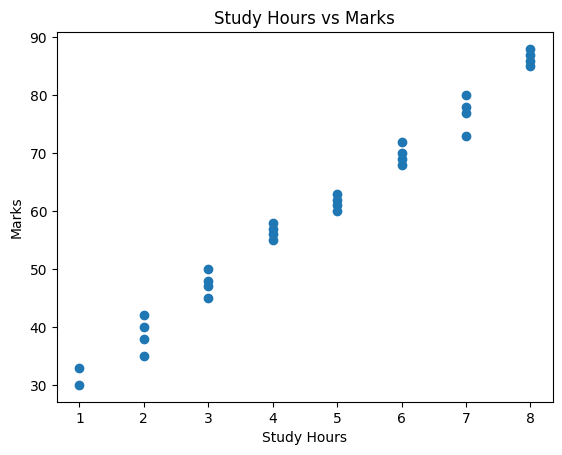

In [11]:
import matplotlib.pyplot as plt

plt.scatter(data['StudyHours'], data['Marks'])
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks")
plt.show()

In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

from sklearn.metrics import accuracy_score
print("KNN Accuracy:", accuracy_score(y_test, pred_knn))

KNN Accuracy: 0.8333333333333334


In [13]:
def suggest_improvement(study, sleep, attendance, mobile):
    if study < 4:
        return "Increase study hours"
    elif sleep < 6:
        return "Improve sleep schedule"
    elif attendance < 75:
        return "Attend more classes"
    elif mobile > 4:
        return "Reduce mobile usage"
    else:
        return "Good performance habits"

print(suggest_improvement(3,5,60,5))

Increase study hours
